<a href="https://colab.research.google.com/github/F-Abir/GEE-Python-API/blob/main/DEM_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import ee

In [2]:
import geemap
import xarray as xr

In [ ]:
!pip install xee

In [4]:
import xee
import numpy as np
import pandas as pd

In [5]:
ee.Authenticate()
ee.Initialize(
    project = 'ee-abirnahraf',
    opt_url = 'https://earthengine-highvolume.googleapis.com'
)

*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_7TDKVSyKvBdmMqW?ref=4i2o6


In [ ]:
map = geemap.Map(basemap = 'ROADMAP')
map

In [14]:
roi = map.draw_last_feature.geometry()


In [15]:
dem = (
    ee.Image("NASA/NASADEM_HGT/001")
    .select([0],['elevation'])
)

dem

In [16]:
xdem = xr.open_dataset(
    dem,
    engine = 'ee',
    crs = 'EPSG:4326',
    geometry = roi,
    scale = 0.001
)

xdem

<xarray.Dataset> Size: 7MB
Dimensions:    (time: 1, lon: 1615, lat: 1129)
Coordinates:
  * time       (time) datetime64[ns] 8B 2000-02-11
  * lon        (lon) float64 13kB 89.66 89.66 89.66 89.66 ... 91.27 91.27 91.27
  * lat        (lat) float64 9kB 22.81 22.81 22.81 22.82 ... 23.94 23.94 23.94
Data variables:
    elevation  (time, lon, lat) float32 7MB ...
Attributes:
    crs:      EPSG:4326

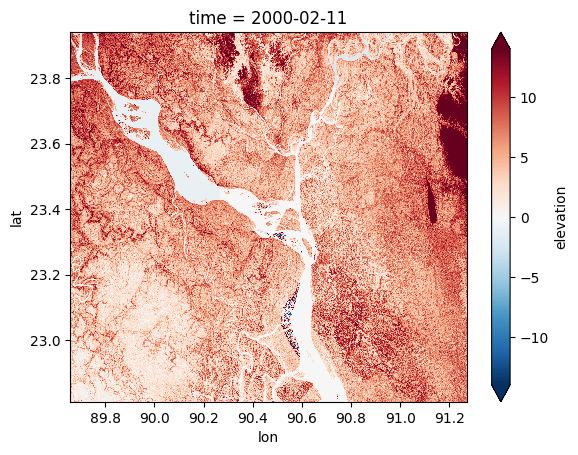

In [17]:
xdem.elevation.plot(
    x = 'lon',
    y = 'lat',
    robust = True
)


In [18]:
df = xdem.to_dataframe()

df


elevation
time       lon       lat                 
2000-02-11 89.657177 22.812131        2.0
                     22.813131        2.0
                     22.814131        1.0
                     22.815131        1.0
                     22.816131        1.0
...                                   ...
           91.271177 23.936131        8.0
                     23.937131       14.0
                     23.938131        7.0
                     23.939131       12.0
                     23.940131       15.0

[1823335 rows x 1 columns]

In [19]:
from sklearn.cluster import KMeans

model = KMeans(n_clusters = 5)

model.fit(df)

df['classes'] = model.predict(df)

df

elevation  classes
time       lon       lat                          
2000-02-11 89.657177 22.812131        2.0        0
                     22.813131        2.0        0
                     22.814131        1.0        0
                     22.815131        1.0        0
                     22.816131        1.0        0
...                                   ...      ...
           91.271177 23.936131        8.0        1
                     23.937131       14.0        4
                     23.938131        7.0        1
                     23.939131       12.0        1
                     23.940131       15.0        4

[1823335 rows x 2 columns]

In [20]:
xarr = df.to_xarray().sortby(['lon','lat'])

xarr

<xarray.Dataset> Size: 15MB
Dimensions:    (time: 1, lon: 1615, lat: 1129)
Coordinates:
  * time       (time) datetime64[ns] 8B 2000-02-11
  * lon        (lon) float64 13kB 89.66 89.66 89.66 89.66 ... 91.27 91.27 91.27
  * lat        (lat) float64 9kB 22.81 22.81 22.81 22.82 ... 23.94 23.94 23.94
Data variables:
    elevation  (time, lon, lat) float32 7MB 2.0 2.0 1.0 1.0 ... 7.0 12.0 15.0
    classes    (time, lon, lat) int32 7MB 0 0 0 0 0 0 0 0 0 ... 3 1 1 1 4 1 1 4

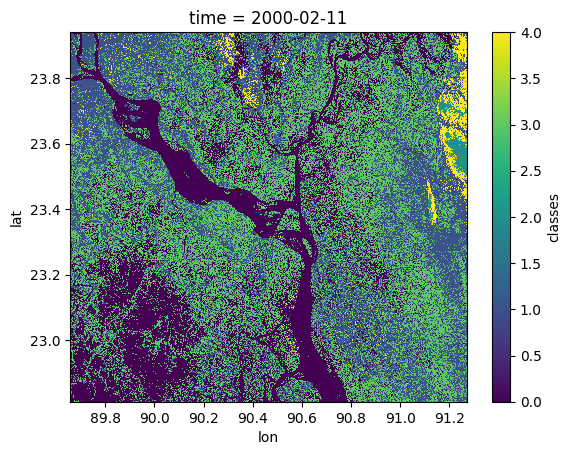

In [21]:
xarr.classes.plot(
    x = 'lon',
    y = 'lat'
)


In [22]:
class_num = np.unique(xarr.classes.values)
class_num

array([0, 1, 2, 3, 4], dtype=int32)

In [23]:
xarr.elevation.where(xarr.classes == 1).mean().values

array(8.64838028)

In [24]:
for i in class_num:
  class_mean = xarr.elevation.where(xarr.classes == i).mean().values.round(2)
  print(f'class {i} average: {class_mean}')
  class_max = xarr.elevation.where(xarr.classes == i).max().values.round(2)
  print(f'class {i} maximum: {class_max}')
  class_min = xarr.elevation.where(xarr.classes == i).min().values.round(2)
  print(f'class {i} minimum: {class_min}')
  print('-----------------------------------')

class 0 average: 1.4
class 0 maximum: 3.0
class 0 minimum: -60.0
-----------------------------------
class 1 average: 8.65
class 1 maximum: 13.0
class 1 minimum: 7.0
-----------------------------------
class 2 average: 40.98
class 2 maximum: 86.0
class 2 minimum: 30.0
-----------------------------------
class 3 average: 4.98
class 3 maximum: 6.0
class 3 minimum: 4.0
-----------------------------------
class 4 average: 18.31
class 4 maximum: 29.0
class 4 minimum: 14.0
-----------------------------------


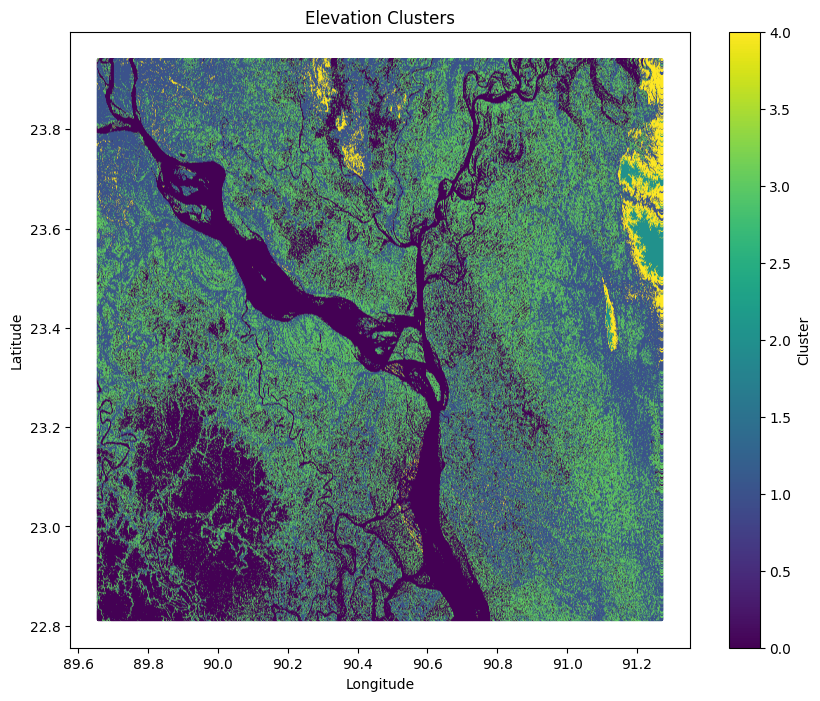

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.scatter(df.index.get_level_values('lon'), df.index.get_level_values('lat'), c=df['classes'], s=1)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Elevation Clusters')
plt.colorbar(label='Cluster')
plt.show()